05 · Topology: planarity, faces, genus, duals and crossings

Every claim below is checked against a value that can be looked up or derived
by hand: K₅ and K₃,₃ are not planar, a tree has exactly one face, a connected
plane graph satisfies **V − E + F = 2**, a convex drawing of Kₙ has exactly
**C(n,4)** crossings. Where the add-on disagrees with the mathematics, the
disagreement is written down.

The operators are `check_planarity`, `calculate_genus`, `compute_faces`,
`validate_crossings`, `visualize_surface`, `create_dual_graph`,
`toggle_dual_graph`, `remove_dual_graph`, `toggle_topo_surface` and
`remove_topo_surface`, in
`SciGraphs/ui/operators/scigraphs/topology_operators.py` over
`SciGraphs/core/algorithms/topology.py`, which wraps NetworkX's Boyer-Myrvold
planarity test.

No internet and no data files: every graph is generated.

## 0 · Setup

In [1]:
import itertools
import math
import pathlib
import random
import sys


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

import bpy
import networkx as nx
import numpy as np

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

from SciGraphs import api as sg

# `use_worktree()` puts this repository ahead of the installed add-on for
# `SciGraphs.core.*`, so the cells below can call the same functions the
# operators call. The operators themselves still come from the installed copy.
from scigraphs_core.algorithms import topology
from scigraphs_core.algorithms.graph import GraphData
from scigraphs_core.coloring.colormaps import sample_colormap
from SciGraphs.core.mesh import geometry

SEED = 19
COLLECTION = "SciGraphs_Topology"

print("networkx", nx.__version__)

networkx 3.6


## 1 · The cast

Eleven graphs in thirteen drawings; two appear twice, drawn two ways, which is
what section 6 is for. All are generated from a formula.

`sg.graphs.from_gdf()` takes GeoDataFrames and none of these graphs is
anywhere, so the constructor is
`SciGraphs.core.mesh.geometry.create_graph_object()`, the add-on's CSV import
path. It honors `node_coordinates`, so the drawing is ours.

> **Two things that bite.** `create_graph_object` links into
> `bpy.context.collection` (`SciGraphs/core/mesh/geometry.py:376`), which is
> `None` under `blender -b` once the start-up collection has been removed: an
> `AttributeError` on a call that has nothing to do with collections.
> `use_collection()` below makes one and marks it active first.
> `create_dual_graph` does the same at
> `SciGraphs/ui/operators/scigraphs/topology_operators.py:477`.
>
> The coordinates are also **renormalized** to about ten units across. The
> transform is uniform, so it preserves planarity and every crossing, which is
> all this notebook reads off the geometry.

Three more properties of that constructor. Node identifiers are stored as one
comma-joined string (`geometry.py:383` nodes, `:394` edges) and split again by
`layouts/common.py:118` and `:126`, so a comma inside a label shifts every
identifier after it; every label here is `str(int)`. Isolated vertices survive
only because the node list is explicit, where the CSV route derives its nodes
from the edge list and cannot express a vertex with no edges, which the
edgeless cases in section 3 need. And positions are set once, at construction:
no layout operator is called, for the reason section 6 gives.

In [2]:
def use_collection(name=COLLECTION):
    """Make `name` the active collection, creating it if necessary."""
    coll = sg.graphs.collection(name)
    view_layer = bpy.context.view_layer
    for layer in view_layer.layer_collection.children:
        if layer.collection is coll:
            view_layer.active_layer_collection = layer
            return coll
    view_layer.active_layer_collection = view_layer.layer_collection
    return coll


def build(graph, positions, name):
    """Materialize a NetworkX graph in Blender at the given 2D positions."""
    use_collection()
    data = GraphData([str(v) for v in graph.nodes()],
                     [(str(u), str(v)) for u, v in graph.edges()])
    data.node_coordinates = {
        str(v): (float(positions[v][0]), float(positions[v][1]), 0.0)
        for v in graph.nodes()}
    with nb.quiet():
        obj = geometry.create_graph_object(data, is_directed=False,
                                           remove_self_loops=True)
    obj.name = name
    obj.data.name = f"{name}_Mesh"
    obj["topo_case"] = name
    return obj


def act(obj):
    """Make `obj` the active and only selected object, headless-safe."""
    for other in bpy.data.objects:
        other.select_set(False)
    bpy.context.view_layer.objects.active = obj
    obj.select_set(True)
    return obj


def convex(graph, radius=5.0):
    """The convex (circular) drawing: every node on a circle, in node order."""
    count = graph.number_of_nodes()
    return {v: (radius * math.cos(2 * math.pi * i / count),
            radius * math.sin(2 * math.pi * i / count))
            for i, v in enumerate(graph.nodes())}

The one graph that is not a textbook name: a 6 × 6 lattice with
twelve edges knocked out. A plain grid has faces of one size; perforating it
spreads the sizes while keeping the answer computable. The removals are
seeded, and each is kept only if the result stays connected with no node of
degree 1, since a degree-1 node adds a dangling edge and those are section 5's
topic.

In [3]:
def perforated_grid(side=6, cuts=12, seed=SEED):
    base = nx.grid_2d_graph(side, side)
    order = list(base.nodes())
    rng = random.Random(seed)
    candidates = sorted(base.edges())
    rng.shuffle(candidates)
    removed = 0
    for u, v in candidates:
        if removed >= cuts:
            break
        base.remove_edge(u, v)
        if nx.is_connected(base) and min(d for _, d in base.degree()) >= 2:
            removed += 1
        else:
            base.add_edge(u, v)
    mapping = {v: i for i, v in enumerate(order)}
    graph = nx.relabel_nodes(base, mapping)
    positions = {mapping[v]: (float(v[0]), float(v[1])) for v in order}
    return graph, positions, removed


grid, grid_pos, cuts_made = perforated_grid()

lattice = nx.triangular_lattice_graph(5, 9)
lattice_pos = nx.get_node_attributes(lattice, "pos")
lattice = nx.convert_node_labels_to_integers(lattice, label_attribute="orig")
lattice_pos = {i: lattice.nodes[i]["pos"] for i in lattice.nodes()}

tree = nx.balanced_tree(2, 3)
octahedron = nx.octahedral_graph()
two_triangles = nx.disjoint_union(nx.cycle_graph(3), nx.cycle_graph(3))
two_triangles_pos = {0: (-3, 0), 1: (-1, 0), 2: (-2, 2),
                     3: (1, 0), 4: (3, 0), 5: (2, 2)}

# The last column is from the literature, not from NetworkX: checking
# `check_planarity_nx` against `nx.check_planarity` would only prove that a
# wrapper wraps.
CAST = [
    # name             graph                              drawing            planar
    ("Grid",           grid,                              grid_pos,          True),
    ("Lattice",        lattice,                           lattice_pos,       True),
    ("Tree",           tree,                              None,              True),
    ("C4",             nx.cycle_graph(4),                 None,              True),
    ("Octahedron",     octahedron,                        None,              True),
    ("Octa_convex",    octahedron,                        convex(octahedron), True),
    ("Grid_convex",    grid,                              convex(grid, 6.0), True),
    ("TwoTriangles",   two_triangles,                     two_triangles_pos, True),
    ("K5",             nx.complete_graph(5),              None,              False),
    ("K33",            nx.complete_bipartite_graph(3, 3), None,              False),
    ("K7",             nx.complete_graph(7),              None,              False),
    ("K8",             nx.complete_graph(8),              None,              False),
    ("Petersen",       nx.petersen_graph(),               None,              False),
]

sg.graphs.clear_scene(keep_anchor=False)

objects, graphs, known_planar = {}, {}, {}
for name, graph, positions, planar in CAST:
    if positions is None:
        positions = (nx.planar_layout(graph, scale=5.0) if planar
                     else convex(graph))
    objects[name] = build(graph, positions, name)
    graphs[name] = graph
    known_planar[name] = planar

print(f"perforated grid: {cuts_made} edges removed, "
      f"connected={nx.is_connected(grid)}")
print(f"{len(objects)} graphs in the scene\n")
print(f"{'name':<14}{'V':>4}{'E':>5}   known")
for name, graph, _positions, planar in CAST:
    print(f"{name:<14}{graph.number_of_nodes():>4}{graph.number_of_edges():>5}"
          f"   {'planar' if planar else 'NOT planar'}")

check("every graph reached the scene",
      all(obj is not None for obj in objects.values()))
check("the drawings survived the renormalization",
      all(len(obj.data.vertices) == graphs[name].number_of_nodes()
      for name, obj in objects.items()))


Creating graph object with 36 nodes...
  Coordinates applied for 36/36 nodes in 0.00s
  Vertices created in 0.00s
  48 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
Total graph creation time: 0.00s

Creating graph object with 33 nodes...
  Coordinates applied for 33/33 nodes in 0.00s
  Vertices created in 0.00s
  77 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
Total graph creation time: 0.00s

Creating graph object with 15 nodes...
  Coordinates applied for 15/15 nodes in 0.00s
  Vertices created in 0.00s
  14 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
Total graph creation time: 0.00s

Creating graph object with 4 nodes...
  Coordinates applied for 4/4 nodes in 0.00s
  Vertices created in 0.00s
  4 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
Total graph creation time: 0.00s

Creating graph object with 6 nodes...
  Coordinates applied for 6/6 nodes in 0.00s
  Ve

True

## 2 · Planarity

`check_planarity` runs NetworkX's Boyer-Myrvold test and stores
`topo_is_planar` on the object, plus the Euler quadruple when the graph is
planar. Kuratowski's theorem is why the two non-planar cases below are the
canonical ones: a graph is planar **iff** it contains no subdivision of K₅ or
K₃,₃, the two smallest obstructions (K₅ by vertices, K₃,₃ by edges).

In [4]:
verdicts = {}
for name in objects:
    act(objects[name])
    with nb.quiet():
        bpy.ops.scigraphs.check_planarity()
    verdicts[name] = bool(objects[name]["topo_is_planar"])

wrong = [n for n in verdicts if verdicts[n] != known_planar[n]]
for name in objects:
    mark = "ok " if verdicts[name] == known_planar[name] else "WRONG"
    print(f"  {name:<14} operator says {'planar' if verdicts[name] else 'NOT planar':<10}"
          f" known {'planar' if known_planar[name] else 'NOT planar':<10} {mark}")

check("the planarity test agrees with the literature on all 13 graphs",
      not wrong, f"disagreements: {wrong}" if wrong else "")

Info: Graph is PLANAR: V=36, E=48, F=14, chi=2
Info: Graph is PLANAR: V=33, E=77, F=46, chi=2
Info: Graph is PLANAR: V=15, E=14, F=1, chi=2
Info: Graph is PLANAR: V=4, E=4, F=2, chi=2
Info: Graph is PLANAR: V=6, E=12, F=8, chi=2
Info: Graph is PLANAR: V=6, E=12, F=8, chi=2
Info: Graph is PLANAR: V=36, E=48, F=14, chi=2
Info: Graph is PLANAR: V=6, E=6, F=4, chi=4
  Grid           operator says planar     known planar     ok 
  Lattice        operator says planar     known planar     ok 
  Tree           operator says planar     known planar     ok 
  C4             operator says planar     known planar     ok 
  Octahedron     operator says planar     known planar     ok 
  Octa_convex    operator says planar     known planar     ok 
  Grid_convex    operator says planar     known planar     ok 
  TwoTriangles   operator says planar     known planar     ok 
  K5             operator says NOT planar known NOT planar ok 
  K33            operator says NOT planar known NOT planar ok 
  K7 

True

Both drawings of the octahedron come back planar, and so does
the circular drawing of the grid: **planarity is a property of the graph**,
and `check_planarity` never looks at the vertex positions. Section 6 is about
the operator that does.

When the answer is *no*, the branch that reports it tries to name the
obstruction it found, and cannot.

In [5]:
act(objects["K5"])
print("K5 stored kuratowski type:", objects["K5"].get("topo_kuratowski_type"))
print("K33 stored kuratowski type:", objects["K33"].get("topo_kuratowski_type"))

probe = topology.detect_kuratowski_subgraph(
    GraphData([str(v) for v in nx.complete_graph(5).nodes()],
              [(str(u), str(v)) for u, v in nx.complete_graph(5).edges()]))
print("detect_kuratowski_subgraph ->", probe)
print("networkx has planarity.kuratowski_subgraph:",
      hasattr(nx.algorithms.planarity, "kuratowski_subgraph"))

K5 stored kuratowski type: unknown
K33 stored kuratowski type: unknown
detect_kuratowski_subgraph -> {'is_planar': False, 'kuratowski_type': 'unknown', 'subgraph_nodes': None}
networkx has planarity.kuratowski_subgraph: False


> **Operator defect.**
> `topology.detect_kuratowski_subgraph` calls
> `nx.algorithms.planarity.kuratowski_subgraph(G)`
> (`SciGraphs/core/algorithms/topology.py:356`). No such function exists in
> NetworkX, in 3.6 or any release. The call raises
> `AttributeError`, the bare `except Exception` two lines below
> (`topology.py:374`) swallows it, and the function returns
> `kuratowski_type='unknown'` for **every** non-planar graph. The operator
> reports "Graph is NON-PLANAR (contains unknown subdivision)"
> (`topology_operators.py:52`), which reads like a hedge and is dead code.
>
> `nx.check_planarity(G, counterexample=True)` returns a Kuratowski subgraph
> as its second element. The classification below it (K₅ if the subgraph has
> ≥ 5 nodes and ≥ 10 edges, K₃,₃ otherwise, `topology.py:364`) is also wrong
> on its own terms: a *subdivision* of K₃,₃ with two extra vertices has 11
> edges and would be reported as K₅.

## 3 · Faces and Euler's formula

`compute_faces` traverses the rotation system of the planar embedding and
writes `topo_num_faces` on the object and a `face_id` integer attribute on the
mesh. The number on its own is not checkable; the identity is:

> For a **connected** graph drawn in the plane, **V − E + F = 2**, counting
> the unbounded outer face.

So the test is not "does it return 14" but "does 36 − 48 + 14 equal 2".

In [6]:
connected_planar = ["Grid", "Lattice", "Tree", "C4", "Octahedron"]

print(f"{'name':<12}{'V':>4}{'E':>5}{'F':>5}{'chi':>6}   V-E+F")
euler_ok = True
for name in connected_planar:
    obj = objects[name]
    act(obj)
    with nb.quiet():
        bpy.ops.scigraphs.compute_faces()
    V = int(obj["topo_euler_V"])
    E = int(obj["topo_euler_E"])
    F = int(obj["topo_num_faces"])
    chi = V - E + F
    euler_ok = euler_ok and chi == 2
    print(f"{name:<12}{V:>4}{E:>5}{F:>5}{chi:>6}   {V} - {E} + {F} = {chi}")

check("V - E + F = 2 on every connected planar graph in the cast",
      euler_ok)

name           V    E    F   chi   V-E+F
Info: Found 14 faces. Attribute 'face_id' created.
Grid          36   48   14     2   36 - 48 + 14 = 2
Info: Found 46 faces. Attribute 'face_id' created.
Lattice       33   77   46     2   33 - 77 + 46 = 2
Info: Found 1 faces. Attribute 'face_id' created.
Tree          15   14    1     2   15 - 14 + 1 = 2
Info: Found 2 faces. Attribute 'face_id' created.
C4             4    4    2     2   4 - 4 + 2 = 2
Info: Found 8 faces. Attribute 'face_id' created.
Octahedron     6   12    8     2   6 - 12 + 8 = 2
[PASS] V - E + F = 2 on every connected planar graph in the cast


True

The tree decides whether the **outer face** is counted. A tree
has no cycle, so it bounds no region: the only face is the unbounded one and F
must be 1. An implementation that dropped the outer face would return 0 here,
and V − E + F would come out 1 instead of 2.

In [7]:
V, E = tree.number_of_nodes(), tree.number_of_edges()
F = int(objects["Tree"]["topo_num_faces"])
print(f"tree: V={V} E={E} F={F}  (E = V - 1 = {V - 1}, so F must be 1)")
check("the outer face is counted", F == 1)

tree: V=15 E=14 F=1  (E = V - 1 = 14, so F must be 1)
[PASS] the outer face is counted


True

Every edge lies on exactly two face boundaries (the same face
twice if it is a bridge), so

> **Σ deg(f) = 2E**

which catches a traversal that walks an edge once instead of twice.
`topo_faces` is the face list itself, stored as the `repr()` of a list of
lists of node indices.

In [8]:
faces_grid = eval(objects["Grid"]["topo_faces"])
degrees = sorted(len(face) for face in faces_grid)
print("grid face degrees:", degrees)
print(f"sum {sum(degrees)}   2E = {2 * grid.number_of_edges()}")
check("every edge is on exactly two face boundaries",
      sum(degrees) == 2 * grid.number_of_edges())

grid face degrees: [4, 4, 4, 4, 4, 4, 4, 4, 6, 6, 8, 12, 12, 20]
sum 96   2E = 96
[PASS] every edge is on exactly two face boundaries


True

### Where the identity stops holding

Two boundary cases, both accepted without complaint.

**Disconnected graphs.** `TwoTriangles` is two disjoint triangles. Drawn in
the plane they share one unbounded face, so the honest count is F = 3 and the
generalized identity is V − E + F = 1 + C, with C the number of components:
6 − 6 + 3 = 3.

In [9]:
act(objects["TwoTriangles"])
with nb.quiet():
    bpy.ops.scigraphs.check_planarity()
obj = objects["TwoTriangles"]
V = int(obj["topo_euler_V"])
E = int(obj["topo_euler_E"])
F = int(obj["topo_euler_F"])
components = nx.number_connected_components(two_triangles)
print(f"V={V} E={E} F={F} chi={obj['topo_euler_chi']}  components={components}")
print(f"  drawn in one plane:      V - E + F = 1 + C = {1 + components}, so F = {E - V + 1 + components}")
print(f"  one sphere per component: V - E + F = 2C = {2 * components}, so F = {E - V + 2 * components}")

check("the reported chi is 2C, not 2",
      V - E + F == 2 * components,
      f"{V} - {E} + {F} = {V - E + F}")

Info: Graph is PLANAR: V=6, E=6, F=4, chi=4
V=6 E=6 F=4 chi=4  components=2
  drawn in one plane:      V - E + F = 1 + C = 3, so F = 3
  one sphere per component: V - E + F = 2C = 4, so F = 4
[PASS] the reported chi is 2C, not 2 — 6 - 6 + 4 = 4


True

> **Worth knowing rather than a defect.** The face traversal
> walks each component's outer boundary separately (`topology.py:125`), so it
> counts one outer face **per component**. That is the Euler characteristic of
> C disjoint spheres, χ = 2C, and the only answer available from a
> combinatorial embedding, which does not record how the components are nested
> in a common plane. The docstring above it says otherwise, "For planar graphs
> embedded in a plane: chi = 2" (`topology.py:62`), and the operator reports
> `chi=4` for a graph it calls planar. Read `topo_euler_chi` as 2C and check
> connectivity yourself before believing a 2.

**Graphs with no edges.** An isolated vertex has no half-edges, so the
traversal never starts and it contributes no face at all, not even the one it
sits in.

In [10]:
for label, graph in (("one isolated node", nx.empty_graph(1)),
                     ("three isolated nodes", nx.empty_graph(3)),
                     ("triangle + isolated node",
                     nx.disjoint_union(nx.cycle_graph(3), nx.empty_graph(1)))):
    data = GraphData([str(v) for v in graph.nodes()],
                     [(str(u), str(v)) for u, v in graph.edges()])
    planar, embedding = topology.check_planarity_nx(data)
    euler = topology.get_euler_characteristic(data, embedding)
    parts = nx.number_connected_components(graph)
    print(f"  {label:<26} V={euler['V']} E={euler['E']} "
          f"F={euler['F']} chi={euler['chi']}   expected chi=2C={2 * parts}")

check("an edgeless component contributes no face at all",
      topology.get_euler_characteristic(
      GraphData(["0"], []),
      topology.check_planarity_nx(GraphData(["0"], []))[1])["F"] == 0,
      "F=0 for a single node; a point drawn in the plane has one face")

  one isolated node          V=1 E=0 F=0 chi=1   expected chi=2C=2
  three isolated nodes       V=3 E=0 F=0 chi=3   expected chi=2C=6
  triangle + isolated node   V=4 E=3 F=2 chi=3   expected chi=2C=4
[PASS] an edgeless component contributes no face at all — F=0 for a single node; a point drawn in the plane has one face


True

### `face_id`, and what it is not

`compute_faces` also writes a point attribute, which reads as "which face this
node belongs to" and is not that: a node belongs to as many faces as it has
incident edges. It holds the **lowest-numbered face containing the node**
(`topology.py:414`), an artifact of the traversal order.

In [11]:
obj = objects["Grid"]
attr = obj.data.attributes["face_id"]
values = np.array([attr.data[i].value for i in range(len(obj.data.vertices))])
used = sorted(set(values.tolist()))
print(f"faces found          {obj['topo_num_faces']}")
print(f"distinct face_id     {len(used)}  ->  {used}")
print(f"nodes on face 0      {int((values == used[0]).sum())} of {len(values)}")

check("face_id is not a partition of the faces",
      len(used) < int(obj["topo_num_faces"]),
      f"{len(used)} labels for {obj['topo_num_faces']} faces")

faces found          14
distinct face_id     6  ->  [0, 1, 2, 3, 6, 11]
nodes on face 0      6 of 36
[PASS] face_id is not a partition of the faces — 6 labels for 14 faces


True

The suite's style: `look='ink'` and its turbo ramp, straight
down through an orthographic camera (`render_eevee`'s default). The color is
`face_id`, on the POINT domain, so it lands on the node spheres and the tubes
take a neutral.

A face label is categorical and turbo is a continuous ramp. Notebook 06
measures this on 18 K-Means labels and finds the closest adjacent pair 55/765
apart in turbo, the best of the five colormaps in the set and still not a
categorical scale. Six labels is easier, and the separations are measured
below rather than assumed.

Notebook 13 diagnosed the other half. Turbo's two **endpoints** are its
darkest stops, so the lowest and highest labels get the dimmest colors
available, and ink's default `edge_color` of 0.13 renders tubes *brighter*
than they are, putting the measurement underneath the wiring. 01 pushed the
neutral below both ends and its value is not low enough. Median luminance out
of 255, projecting every node center through the camera and reading the render
back:

| `edge_color` | tubes (median / p90) | darkest label | |
|---|---|---|---|
| 0.130, ink's default | 98 / 102 | 84 | tubes 14 levels over the data |
| 0.085, notebook 13's | 85 / 89 | 81 | still over |
| **0.060** | **75 / 80** | **83** | under both endpoints |
| 0.045 | 69 / 75 | 80 | under, and the wiring starts to vanish |

The two dark classes are the two ends: label 0 at 88 and label 11 at 83,
against 148, 175, 185 and 221 for the four in between. The difference from 01
is the tube radius: these lattices have a wide node spacing, so `edge_ratio`
puts more lit surface on every tube.

In [12]:
ramp = sample_colormap("turbo", samples=256)
low, high = min(used), max(used)


def turbo_at(value):
    position = 0.0 if high == low else (value - low) / (high - low)
    return np.asarray(ramp[int(round(position * 255))][:3], dtype=float) * 255.0


separations = [float(np.abs(turbo_at(used[i + 1]) - turbo_at(used[i])).sum())
               for i in range(len(used) - 1)]
print("turbo separation between adjacent labels, out of 765:",
      [round(s) for s in separations])
print(f"closest pair: {round(min(separations))}/765 "
      f"(notebook 18 measures 55/765 at 18 labels)")

check("no two adjacent labels are closer than 06's 18-label worst case",
      min(separations) >= 55,
      f"{round(min(separations))}/765")

turbo separation between adjacent labels, out of 765: [220, 118, 128, 372, 358]
closest pair: 118/765 (notebook 18 measures 55/765 at 18 labels)
[PASS] no two adjacent labels are closer than 06's 18-label worst case — 118/765


True

`node_fraction=0.16`, well below the 0.35 default. That default
is calibrated on an irregular point cloud with room between the clusters; a
lattice is the case the README's "string of beads" warning is about. Measured
on this figure: 0.35 gives 34 % ink with the grid buried under its own nodes,
0.22 gives 20 %, and 0.16 gives 13 % with every cut edge visible as a gap. A
figure about *faces* has to show those, since the faces are exactly the gaps.

Info: Geometry Nodes modifier added
Info: Attribute -> face_id  ·  face_id -> turbo [log]  [0 … 11] on Point


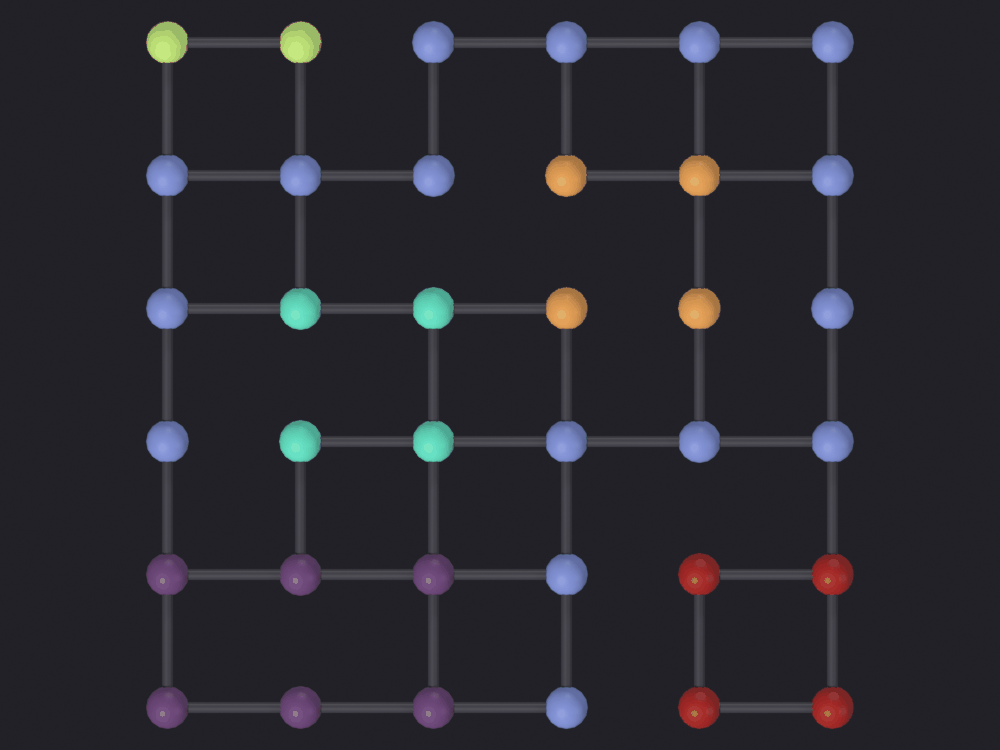

[PASS] 1_faces.png legible — 13.4% ink (healthy range 0.5–60%)


In [13]:
LABEL_EDGE_COLOR = (0.060, 0.056, 0.071)   # measured above; 01's hue, lower value

nb.figure(objects["Grid"], "renders/17_topology/1_faces",
          look='ink', color_attribute="face_id",
          node_fraction=0.16, edge_color=LABEL_EDGE_COLOR)

The label steps up as the traversal works across the drawing,
and the nodes sharing a color are the ones it reached first from the same
face. Read as "the faces of this graph", which the name invites, it is wrong:
14 faces, 6 colors. The dual, next, is the figure that does show the faces.

## 4 · Genus

The genus of a graph is the smallest number of handles a surface needs before
the graph can be drawn on it without crossings. Planar graphs have genus 0;
K₅, K₃,₃, K₇ and the Petersen graph have genus 1, drawing cleanly on a torus;
K₈ has genus 2.

**Computing it exactly is NP-hard** (Thomassen, 1989), so `calculate_genus`
returns two different things instead
(`SciGraphs/core/algorithms/topology.py:263`):

- planar → `genus_exact = 0`, `genus_lower_bound = 0`. Exact: planarity is
  decidable in linear time and genus 0 follows.
- non-planar → `genus_exact = None` and
  `genus_lower_bound = ceil((E − 3V + 6) / 6)`. A **lower bound**, never an
  estimate and never an upper bound, from Euler's inequality for a graph of
  girth 3 on an orientable surface of genus g: E ≤ 3(V − 2 + 2g).

The report line says `Genus >= n` for the second case, the correct reading.
`topo_genus_exact` is not written when the graph is not planar; its absence is
the signal.

In [14]:
GENUS_KNOWN = {"K5": 1, "K33": 1, "K7": 1, "K8": 2, "Petersen": 1,
               "Grid": 0, "Lattice": 0, "Tree": 0, "C4": 0, "Octahedron": 0}

print(f"{'name':<12}{'V':>4}{'E':>5}{'bound':>7}{'exact':>7}   known genus")
bounds = {}
for name in GENUS_KNOWN:
    obj = objects[name]
    act(obj)
    if "topo_genus_exact" in obj.keys():
        del obj["topo_genus_exact"]
    with nb.quiet():
        bpy.ops.scigraphs.calculate_genus()
    bound = int(obj["topo_genus_lower_bound"])
    exact = obj.get("topo_genus_exact")
    bounds[name] = bound
    flag = "" if bound <= GENUS_KNOWN[name] else "  BOUND ABOVE THE TRUTH"
    print(f"{name:<12}{obj['topo_euler_V']:>4}{obj['topo_euler_E']:>5}"
          f"{bound:>7}{str(exact):>7}   {GENUS_KNOWN[name]}{flag}")

check("the bound is never above the true genus",
      all(bounds[n] <= GENUS_KNOWN[n] for n in GENUS_KNOWN))
check("genus is exact exactly when the graph is planar",
      all((objects[n].get("topo_genus_exact") is not None)
      == known_planar[n] for n in GENUS_KNOWN))

name           V    E  bound  exact   known genus
Info: Genus >= 1 (non-planar): V=5, E=10
K5             5   10      1   None   1
Info: Genus >= 0 (non-planar): V=6, E=9
K33            6    9      0   None   1
Info: Genus >= 1 (non-planar): V=7, E=21
K7             7   21      1   None   1
Info: Genus >= 2 (non-planar): V=8, E=28
K8             8   28      2   None   2
Info: Genus >= 0 (non-planar): V=10, E=15
Petersen      10   15      0   None   1
Info: Genus = 0 (planar): V=36, E=48, F=14
Grid          36   48      0      0   0
Info: Genus = 0 (planar): V=33, E=77, F=46
Lattice       33   77      0      0   0
Info: Genus = 0 (planar): V=15, E=14, F=1
Tree          15   14      0      0   0
Info: Genus = 0 (planar): V=4, E=4, F=2
C4             4    4      0      0   0
Info: Genus = 0 (planar): V=6, E=12, F=8
Octahedron     6   12      0      0   0
[PASS] the bound is never above the true genus
[PASS] genus is exact exactly when the graph is planar


True

The bound is tight on K₅, K₇ and K₈ (1, 1 and 2, the true
genera), and for the right reason: those are the graphs whose faces really can
all be triangles. On K₃,₃ and the Petersen graph it returns **0**, for a graph
the same function declared non-planar two lines earlier. A non-planar graph
has genus at least 1 by definition, so 0 contradicts the result already in
hand.

In [15]:
for name in ("K33", "Petersen"):
    graph = graphs[name]
    V, E = graph.number_of_nodes(), graph.number_of_edges()
    girth = nx.girth(graph)
    triangle_bound = math.ceil((E - 3 * V + 6) / 6)
    # Euler's inequality with the real girth: E <= g/(g-2) * (V - 2 + 2g_enus)
    girth_bound = math.ceil((((girth - 2) * E) / girth - V + 2) / 2)
    print(f"{name:<10} V={V} E={E} girth={girth}  "
          f"girth-3 bound {triangle_bound} -> reported {bounds[name]}   "
          f"girth-aware bound {girth_bound}   true genus {GENUS_KNOWN[name]}")

contradiction = [n for n in ("K5", "K33", "K7", "K8", "Petersen")
                 if bounds[n] < 1]
print(f"\nnon-planar graphs reported with a genus bound of 0: {contradiction}")

check("a girth-aware bound recovers genus >= 1 on both of them",
      all(math.ceil(((((nx.girth(graphs[n]) - 2) * graphs[n].number_of_edges())
      / nx.girth(graphs[n])) - graphs[n].number_of_nodes() + 2) / 2) >= 1
      for n in contradiction))

K33        V=6 E=9 girth=4  girth-3 bound 0 -> reported 0   girth-aware bound 1   true genus 1
Petersen   V=10 E=15 girth=5  girth-3 bound -1 -> reported 0   girth-aware bound 1   true genus 1

non-planar graphs reported with a genus bound of 0: ['K33', 'Petersen']
[PASS] a girth-aware bound recovers genus >= 1 on both of them


True

> **Operator defect.**
> `topology.calculate_genus` computes `max(0, ceil((E − 3V + 6) / 6))` at
> `SciGraphs/core/algorithms/topology.py:307` and returns it as
> `genus_lower_bound` without consulting the planarity result it computed at
> line 288. The formula assumes every face is a triangle, right for a complete
> graph and wrong for anything triangle-free: K₃,₃ is bipartite (girth 4) and
> the Petersen graph has girth 5, so their faces need at least 4 and 5 edges.
> Either one-line repair fixes both cases: `max(1, …)` when `is_planar` is
> False, or the girth-aware inequality `E ≤ g/(g − 2) · (V − 2 + 2g_enus)`
> computed above. The report line reads "Genus >= 0 (non-planar)", a statement
> true of every graph in existence, printed as though it were a measurement.

## 5 · The dual graph

`create_dual_graph` builds the **geometric dual** G\*: one vertex per face of
the planar embedding, placed at that face's centroid, and an edge between two
faces for every edge of G they share. It needs a planar embedding, so it
refuses on a non-planar graph and before `check_planarity` has run.

The checkable claim is the first half: **|V(G\*)| = F**.

In [16]:
act(objects["Grid"])
with nb.quiet():
    bpy.ops.scigraphs.create_dual_graph()
dual = bpy.data.objects[objects["Grid"]["topo_dual_child"]]
# The operator parents the dual to the primal, so it inherits the primal's
# transform in every later render. Nothing here moves the primal, but that is
# a trap for whoever does.
dual.parent = None

faces = eval(objects["Grid"]["topo_faces"])
print(f"primal   V={grid.number_of_nodes()} E={grid.number_of_edges()} F={len(faces)}")
print(f"dual     V*={dual['num_nodes']} E*={dual['num_edges']} "
      f"(mesh: {len(dual.data.vertices)} verts, {len(dual.data.edges)} edges)")

check("the dual has one vertex per face",
      int(dual["num_nodes"]) == len(faces),
      f"{dual['num_nodes']} vs {len(faces)} faces")

Info: Dual graph created: 14 faces -> vertices, 29 shared edges -> dual edges
primal   V=36 E=48 F=14
dual     V*=14 E*=29 (mesh: 14 verts, 28 edges)
[PASS] the dual has one vertex per face — 14 vs 14 faces


True

The second half diverges. A geometric dual has **exactly as many
edges as the primal**, because each primal edge is crossed by exactly one dual
edge. This one has fewer, for two separate reasons.

In [17]:
bridges = list(nx.bridges(grid))
parallel = grid.number_of_edges() - int(dual["num_edges"])
print(f"primal edges                {grid.number_of_edges()}")
print(f"dual edges reported         {dual['num_edges']}")
print(f"dual edges in the mesh      {len(dual.data.edges)}")
print(f"bridges in the primal       {len(bridges)}  -> dual self-loops")
print(f"lost to the de-duplication  {parallel}")

check("the dual is missing edges the mathematics requires",
      int(dual["num_edges"]) < grid.number_of_edges(),
      f"{dual['num_edges']} vs {grid.number_of_edges()}")
check("the dual mesh holds fewer edges still than the operator reports",
      len(dual.data.edges) < int(dual["num_edges"]),
      f"{len(dual.data.edges)} in the mesh, {dual['num_edges']} reported")

primal edges                48
dual edges reported         29
dual edges in the mesh      28
bridges in the primal       1  -> dual self-loops
lost to the de-duplication  19
[PASS] the dual is missing edges the mathematics requires — 29 vs 48
[PASS] the dual mesh holds fewer edges still than the operator reports — 28 in the mesh, 29 reported


True

> **Operator limitation.** The dual of a planar graph is in
> general a **multigraph**: two faces sharing three edges are joined by three
> dual edges, and a bridge (an edge with the same face on both sides) becomes
> a dual **self-loop**. Neither survives here.
>
> `topology.compute_geometric_dual_3d` collects the dual edges as unordered
> pairs and then does `dual_edges = list(set(dual_edges))`
> (`SciGraphs/core/algorithms/topology.py:246`), collapsing every parallel
> class to one edge. The bridges do produce their `(f, f)` pairs, so they are
> counted in `num_edges`, but `bmesh.edges.new([v, v])` raises and the
> `except ValueError: pass` at `topology_operators.py:468` drops them, which is
> why the stored `num_edges` is above what the mesh holds. Any dual read out of
> this object is the *simple* dual, and V\* − E\* + F\* will not come back to 2.

### The other dual in this suite

Notebook 17 uses `bpy.ops.scigraphs.create_street_dual_graph()`. The shared
word misleads; the constructions are unrelated:

| | `create_dual_graph` (here) | `create_street_dual_graph` (notebook 17) |
|---|---|---|
| What a node is | a **face** of a planar embedding | a **street segment** |
| What an edge is | two faces sharing a primal edge | two segments sharing an intersection |
| Needs planarity | yes, refuses otherwise | no |
| Needs a drawing | yes, nodes sit at face centroids | no |
| Node count | F | E of the primal |
| Mathematically | the geometric dual G\* | the **line graph** L(G) |

The line graph exists for every graph; the geometric dual only for a planar
one, and it depends on the embedding, so two isomorphic planar graphs can have
non-isomorphic duals. Neither is a special case of the other, and nothing in
the add-on's UI says so.

In [18]:
line_nodes = grid.number_of_edges()
line_edges = sum(d * (d - 1) // 2 for _, d in grid.degree())
print(f"grid: V={grid.number_of_nodes()} E={grid.number_of_edges()} F={len(faces)}")
print(f"  geometric dual  V*={dual['num_nodes']:<4} (= F)")
print(f"  line graph      V ={line_nodes:<4} (= E), E = {line_edges}")
check("the two duals do not even have the same number of nodes",
      int(dual["num_nodes"]) != line_nodes)

grid: V=36 E=48 F=14
  geometric dual  V*=14   (= F)
  line graph      V =48   (= E), E = 89
[PASS] the two duals do not even have the same number of nodes


True

The dual carries no attribute of its own, so the figure needs
one: the size of the face each dual node stands for, a 4-gon, a 6-gon, the
20-gon that is the outer boundary. It varies, which is why the grid was
perforated in section 1.

In [19]:
face_degrees = [len(face) for face in faces]
mesh = dual.data
if "face_degree" in mesh.attributes:
    mesh.attributes.remove(mesh.attributes["face_degree"])
attr = mesh.attributes.new(name="face_degree", type='INT', domain='POINT')
attr.data.foreach_set("value", face_degrees[:len(mesh.vertices)])
print("face degrees:", sorted(face_degrees))

face degrees: [4, 4, 4, 4, 4, 4, 4, 4, 6, 6, 8, 12, 12, 20]


`clip_high_pct=98` because the distribution has one member two
thirds larger than the next: eight 4-gons, two 6-gons, one 8-gon, two 12-gons,
and the outer face bounded by the whole 20-edge perimeter. Left unclipped the
outer face takes the top of the ramp on its own and everything below a 12-gon
is pressed into the bottom stop, the comparison the figure is for.

`vmin`/`vmax` would say the same thing and are silently ineffective:
`scigraphs.color_set_attribute` calls
`fn.update_property_range()` before reading them
(`SciGraphs/ui/coloring/operators.py:374`) and overwrites both. The percentile
pair is the one that survives.

Info: Geometry Nodes modifier added
Info: Attribute -> face_degree  ·  face_degree -> turbo [log]  [4 … 17.92] on Point


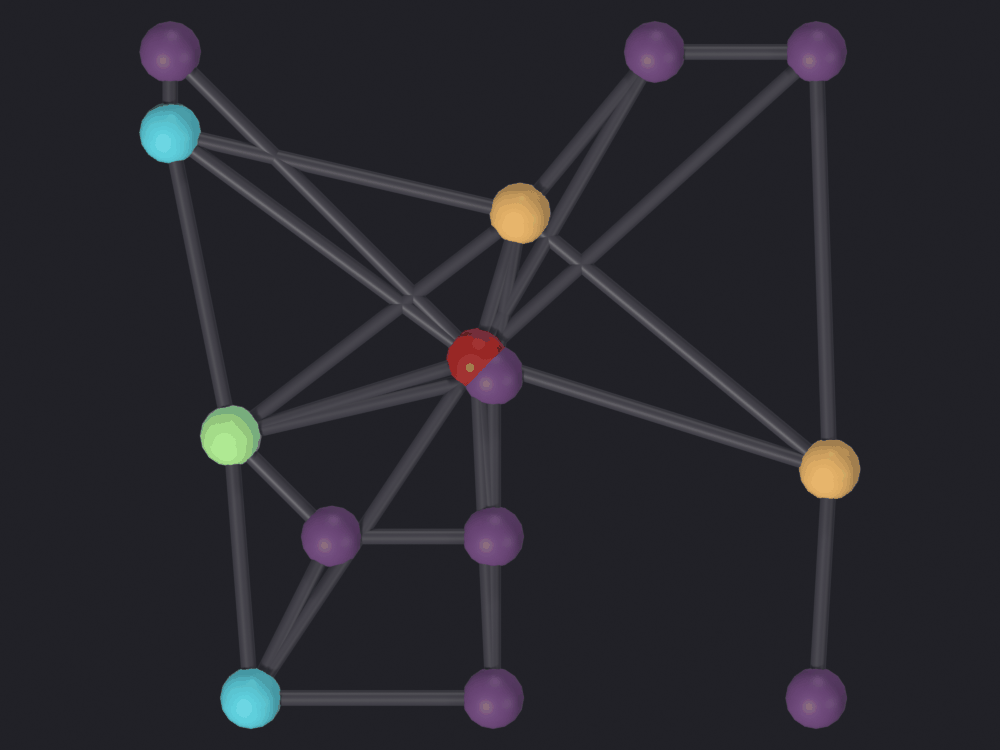

[PASS] 2_dual.png legible — 16.3% ink (healthy range 0.5–60%)


In [20]:
nb.figure(dual, "renders/17_topology/2_dual",
          look='ink', color_attribute="face_degree",
          clip_high_pct=98, node_fraction=0.20,
          edge_color=LABEL_EDGE_COLOR)

Each sphere is a face of the graph in figure 1, sitting where
that face is, colored by how many edges bound it: purple for the 4-gons of
the intact lattice, blue, cyan and yellow for the larger faces the twelve cuts
opened, red for the outer face.

The red one sits in the middle, half hidden behind a purple one, and no node
size fixes it. The outer face is unbounded, so its natural position is outside
everything or at infinity, but `compute_geometric_dual_3d` places every dual
vertex at the arithmetic mean of its face's corners (`topology.py:214`), and
the mean of a perimeter is the center of the figure. So the dual comes with a
hub in the middle joined to every boundary face, sitting on top of whatever
face centroid is nearest the center, at a small fraction of the spacing
between the other dual vertices as measured below. Anything that reads
positions off a dual (a layout, a distance, a second round of `compute_faces`)
inherits that.

In [21]:
outer = int(np.argmax(face_degrees))
centroids = np.array([list(v.co) for v in dual.data.vertices])
to_outer = np.linalg.norm(centroids - centroids[outer], axis=1)
to_outer[outer] = np.inf
spacing = float(np.median([np.sort(np.linalg.norm(centroids - c, axis=1))[1]
                for c in centroids]))
print(f"outer face          index {outer}, degree {face_degrees[outer]}")
print(f"nearest other dual vertex   {to_outer.min():.3f} units")
print(f"median dual vertex spacing  {spacing:.3f} units")
print(f"ratio                       {to_outer.min() / spacing:.2f}")

check("the outer face's vertex lands on top of another one",
      to_outer.min() < 0.25 * spacing,
      f"{to_outer.min() / spacing:.0%} of the median spacing")

outer face          index 1, degree 20
nearest other dual vertex   0.283 units
median dual vertex spacing  1.939 units
ratio                       0.15
[PASS] the outer face's vertex lands on top of another one — 15% of the median spacing


True

It also reads badly from turbo's *other* end. The outer face is
the top of the ramp, turbo's dark red, so the darkest node class and the
brightest are both endpoint colors. Sampled through the camera, the 4-gons
come out at luminance 91, the 6-, 8- and 12-gons at 164, 189 and 211, and the
outer face at 75, level with the tubes at 76 and below every face it is larger
than. Nothing in the render settings moves it: 75 is what turbo's top stop is
worth under this rig, and dropping `edge_color` further only takes the wiring
with it.

### `toggle_dual_graph` and `remove_dual_graph`

`toggle` flips `hide_viewport` and mirrors it onto `hide_render`, so a hidden
dual stays out of the renders below; `remove` deletes the object and the
`topo_dual_child` key with it. Both read `topo_dual_child` off the **active**
object, so the primal has to be active, not the dual.

In [22]:
act(objects["Grid"])
with nb.quiet():
    bpy.ops.scigraphs.toggle_dual_graph()
print("after one toggle: hidden =", dual.hide_viewport,
      " hide_render =", dual.hide_render)
with nb.quiet():
    bpy.ops.scigraphs.toggle_dual_graph()
print("after two       : hidden =", dual.hide_viewport)
check("toggling twice is the identity", not dual.hide_viewport)

Info: Dual graph hidden
after one toggle: hidden = True  hide_render = True
Info: Dual graph visible
after two       : hidden = False
[PASS] toggling twice is the identity


True

## 6 · Crossings

`validate_crossings` is the one operator here that reads the vertex positions,
so everything it says is about the **drawing**, not the graph. `check_planarity`
asks whether the graph *can* be drawn without crossings; `validate_crossings`
asks whether *this drawing* has any. A planar graph drawn badly has crossings,
and getting them down is a layout's job, notebook 02's subject.

> **Set the positions before you measure them.** `edge_crossings` below is an
> **EDGE**-domain attribute, and every layout operator ends by calling
> `geometry.rebuild_edges`, which removes every bmesh edge
> (`SciGraphs/core/mesh/geometry.py:1226`) and builds them again from
> `edges_data`. The attribute survives by name and comes back **zero
> everywhere**, verified below by writing 7 onto every edge, calling
> `rebuild_edges` and reading 0 back. Nothing raises. That is why this notebook
> sets its coordinates in `create_graph_object` and never calls a layout.

In [23]:
# Write 7 onto every edge of a throwaway C4, call the function every layout
# operator calls, read it back.
probe = build(nx.cycle_graph(4), {0: (0, 0), 1: (2, 0), 2: (2, 2), 3: (0, 2)},
              "Probe_C4")
attr = probe.data.attributes.new(name="probe_edge", type='INT', domain='EDGE')
attr.data.foreach_set("value", [7] * len(probe.data.edges))
written = {probe.data.attributes["probe_edge"].data[i].value
           for i in range(len(probe.data.edges))}
geometry.rebuild_edges(probe)
survivor = probe.data.attributes.get("probe_edge")
read_back = ({survivor.data[i].value for i in range(len(probe.data.edges))}
             if survivor else None)
print(f"edge attribute written {written}, read back after rebuild_edges {read_back}")
check("rebuild_edges keeps the attribute and zeroes every value",
      read_back == {0}, "no exception, no warning")
bpy.data.objects.remove(probe, do_unlink=True)


Creating graph object with 4 nodes...
  Coordinates applied for 4/4 nodes in 0.00s
  Vertices created in 0.00s
  4 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
Total graph creation time: 0.00s
edge attribute written {7}, read back after rebuild_edges {0}
[PASS] rebuild_edges keeps the attribute and zeroes every value — no exception, no warning


The oracle that makes the counts below checkable is
combinatorial and touches no geometry: in a drawing with every vertex on a
circle, two chords cross **iff** their four endpoints alternate around it.
Counting alternating quadruples is an independent answer, and for Kₙ it
reproduces the textbook **C(n,4)**: every choice of four vertices spans one
quadrilateral and contributes its two diagonals.

In [24]:
def convex_crossings(graph):
    """Crossings of the convex drawing, counted by interleaving alone."""
    order = {v: i for i, v in enumerate(graph.nodes())}
    total = 0
    for (a, b), (c, d) in itertools.combinations(graph.edges(), 2):
        if len({a, b, c, d}) < 4:
            continue
        first, second = sorted((order[a], order[b]))
        third, fourth = sorted((order[c], order[d]))
        if first < third < second < fourth or third < first < fourth < second:
            total += 1
    return total


for n in (4, 5, 6):
    complete = nx.complete_graph(n)
    obj = build(complete, convex(complete), f"K{n}_convex")
    act(obj)
    with nb.quiet():
        bpy.ops.scigraphs.validate_crossings()
    reported = int(obj["topo_num_crossings"])
    print(f"  K{n} convex: operator {reported}, interleaving "
          f"{convex_crossings(complete)}, C({n},4) = {math.comb(n, 4)}")
    check(f"convex K{n}: operator = interleaving = C({n},4)",
          reported == convex_crossings(complete) == math.comb(n, 4))
    bpy.data.objects.remove(obj, do_unlink=True)

# Not a formula in disguise: it also answers for a graph with no closed form.
k33 = graphs["K33"]
obj = build(k33, convex(k33), "K33_convex")
act(obj)
with nb.quiet():
    bpy.ops.scigraphs.validate_crossings()
print(f"  K3,3 convex: operator {int(obj['topo_num_crossings'])}, "
      f"interleaving {convex_crossings(k33)}")
check("convex K3,3: operator = interleaving",
      int(obj["topo_num_crossings"]) == convex_crossings(k33))
bpy.data.objects.remove(obj, do_unlink=True)


Creating graph object with 4 nodes...
  Coordinates applied for 4/4 nodes in 0.00s
  Vertices created in 0.00s
  6 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
Total graph creation time: 0.00s
  K4 convex: operator 1, interleaving 1, C(4,4) = 1
[PASS] convex K4: operator = interleaving = C(4,4)

Creating graph object with 5 nodes...
  Coordinates applied for 5/5 nodes in 0.00s
  Vertices created in 0.00s
  10 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
Total graph creation time: 0.00s
  K5 convex: operator 5, interleaving 5, C(5,4) = 5
[PASS] convex K5: operator = interleaving = C(5,4)

Creating graph object with 6 nodes...
  Coordinates applied for 6/6 nodes in 0.00s
  Vertices created in 0.00s
  15 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
Total graph creation time: 0.00s
  K6 convex: operator 15, interleaving 15, C(6,4) = 15
[PASS] convex K6: operator = interleaving = C(6,4)

Creating g

### The same graph, two drawings

In [25]:
def crossings_per_edge(obj):
    """Run the detector and return one count per mesh edge, in mesh order."""
    vertices = [list(v.co) for v in obj.data.vertices]
    edges = [(e.vertices[0], e.vertices[1]) for e in obj.data.edges]
    result = topology.detect_edge_crossings_3d(vertices, edges, tolerance=0.01)
    counts = {edge: 0 for edge in edges}
    for first, second in result["crossing_pairs"]:
        counts[first] = counts.get(first, 0) + 1
        counts[second] = counts.get(second, 0) + 1
    return [counts[edge] for edge in edges], result["num_crossings"]


def store_crossings(obj):
    per_edge, total = crossings_per_edge(obj)
    mesh = obj.data
    if "edge_crossings" in mesh.attributes:
        mesh.attributes.remove(mesh.attributes["edge_crossings"])
    attr = mesh.attributes.new(name="edge_crossings", type='INT', domain='EDGE')
    attr.data.foreach_set("value", per_edge)
    return per_edge, total


for name in ("Grid", "Grid_convex"):
    obj = objects[name]
    act(obj)
    with nb.quiet():
        bpy.ops.scigraphs.validate_crossings()
    per_edge, total = store_crossings(obj)
    print(f"  {name:<12} planar={known_planar.get(name, False)!s:<5} "
          f"operator {int(obj['topo_num_crossings']):>3} crossings, "
          f"per edge {min(per_edge)} to {max(per_edge)}")
print(f"  the convex drawing agrees with the interleaving oracle: "
      f"{convex_crossings(grid)}")

check("the operator and the per-edge tally agree",
      sum(crossings_per_edge(objects['Grid_convex'])[0]) ==
      2 * int(objects['Grid_convex']["topo_num_crossings"]))
check("the operator agrees with the interleaving oracle on the circle",
      int(objects["Grid_convex"]["topo_num_crossings"])
      == convex_crossings(grid))
check("the same planar graph goes from 78 crossings to 0 by moving nodes",
      int(objects["Grid_convex"]["topo_num_crossings"]) > 0
      and int(objects["Grid"]["topo_num_crossings"]) == 0)

Info: Embedding is crossing-free!
  Grid         planar=True  operator   0 crossings, per edge 0 to 0
  Grid_convex  planar=True  operator  78 crossings, per edge 0 to 9
  the convex drawing agrees with the interleaving oracle: 78
[PASS] the operator and the per-edge tally agree
[PASS] the operator agrees with the interleaving oracle on the circle
[PASS] the same planar graph goes from 78 crossings to 0 by moving nodes


True

Same style, same camera. The color is `edge_crossings`, on the
EDGE domain, so the ramp lands on the tubes and the node spheres take the
per-vertex average of the edges meeting there, a real quantity on the same
scale (see `sg.render.color_graph`): a bright node is a node whose edges all
cross something. `node_fraction=0.14`, lower again than figure 1's 0.16,
because on a circular drawing the tubes carry the measurement.

  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_crossings  ·  edge_crossings -> turbo [log]  [0 … 9] on Point


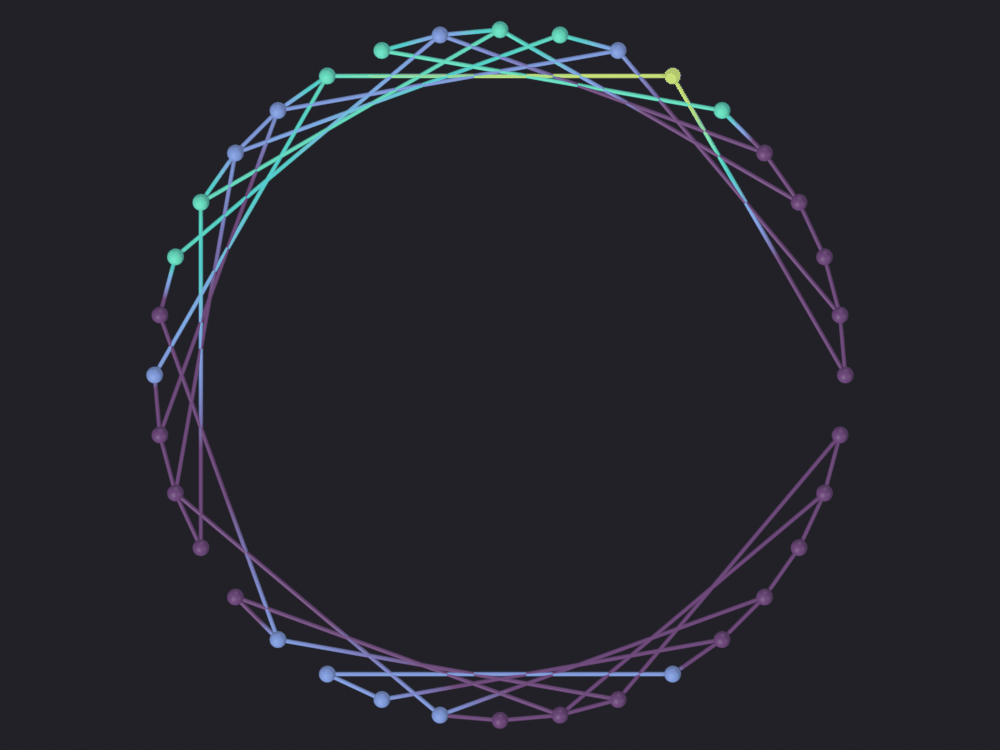

[PASS] 3_crossings_convex.png legible — 6.7% ink (healthy range 0.5–60%)


In [26]:
nb.figure(objects["Grid_convex"],
          "renders/17_topology/3_crossings_convex",
          look='ink', color_attribute="edge_crossings",
          node_fraction=0.14)

The same 36 nodes and 48 edges put back where the lattice has
them. **This figure is deliberately one flat color, and that is the result.**
`edge_crossings` is 0 on every edge, so the ramp has nothing to span: the
coloring reports a range of `[0 … 1e-09]` and everything lands on turbo's
bottom stop, a dark blue-purple, the weakest color in the look. A constant
attribute on a continuous ramp always lands on an endpoint and both of turbo's
endpoints are dark. This figure carries 12 % ink where the convex drawing
above carries 7 %, so it is uniform rather than dim, which is what "no edge
crosses any other" looks like.

  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_crossings  ·  edge_crossings -> turbo [log]  [0 … 1e-09] on Point


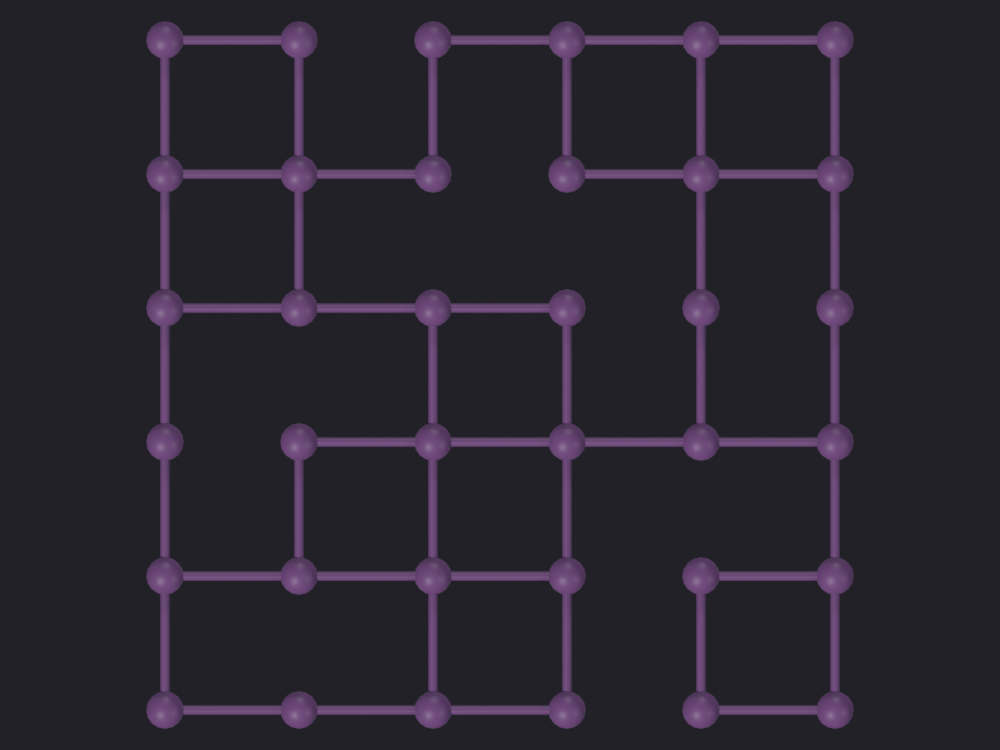

[PASS] 4_crossings_free.png legible — 11.6% ink (healthy range 0.5–60%)


In [27]:
nb.figure(objects["Grid"], "renders/17_topology/4_crossings_free",
          look='ink', color_attribute="edge_crossings",
          node_fraction=0.14)

### When zero is not available

K₅ is not planar, so no drawing of it reaches zero. Its **crossing number**,
the minimum over all drawings, is 1, and the convex drawing measured above is
nowhere near it: five crossings, one per C(5,4) quadrilateral.

One crossing is reachable with straight lines, and the construction makes the
forcing visible. Draw K₄ planar: a triangle A B C with D strictly inside,
joined to all three, giving six edges, no crossings and four faces. Add E
inside the face A B D, joined to A, B and D without crossing anything. The
last edge, E-C, has to leave that triangle, and the only way out crosses one
of its three edges.

In [28]:
K5_DRAWING = {0: (-4.0, -2.0),   # A  \
              1: (4.0, -2.0),    # B   } the outer triangle
              2: (0.4, 5.0),     # C  /
              3: (1.5, 0.2),     # D, inside A B C
              4: (-1.0, -1.7)}   # E, inside the face A B D, low and left
best = build(nx.complete_graph(5), K5_DRAWING, "K5_best")
act(best)
with nb.quiet():
    bpy.ops.scigraphs.validate_crossings()
print("K5 convex        : 5 crossings  (C(5,4), measured above)")
print(f"K5 hand-drawn    : {int(best['topo_num_crossings'])} crossing")
print("crossing number of K5, the minimum over every drawing: 1")
check("the hand-drawn K5 achieves the crossing number",
      int(best["topo_num_crossings"]) == 1)
check("but it cannot reach zero, and nothing can",
      int(best["topo_num_crossings"]) >= 1)


Creating graph object with 5 nodes...
  Coordinates applied for 5/5 nodes in 0.00s
  Vertices created in 0.00s
  10 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
Total graph creation time: 0.00s
K5 convex        : 5 crossings  (C(5,4), measured above)
K5 hand-drawn    : 1 crossing
crossing number of K5, the minimum over every drawing: 1
[PASS] the hand-drawn K5 achieves the crossing number
[PASS] but it cannot reach zero, and nothing can


True

This figure is colored by a node attribute where the two above
it use an edge one. The only way an EDGE-domain attribute reaches a tube is
`_promote_edge_attributes_to_point`, which re-domains it onto the vertices, so
Blender **averages the edges meeting at each node** on the way. On the sparse
grid that is harmless. On a five- or six-node complete graph it destroys the
figure: K₅ in convex position is vertex-transitive, every vertex meets two
0-crossing edges and two 2-crossing edges, every average is 1, and the render
comes back a single flat green with the pentagon and its diagonals
indistinguishable. Convex K₃,₃ does the same, with per-edge counts of 0, 2 and
4. Both were rendered and both discarded.

So the measurement moves to the domain that can carry it: which **vertices**
the unavoidable crossing touches. Four of the five, a two-value attribute on
turbo's two dark ends, which the same `edge_color` of 0.060 answers.

vertices on a crossing edge: [0, 2, 3, 4] of 5
[PASS] one vertex of the five is not involved
Info: Geometry Nodes modifier added
Info: Attribute -> in_crossing  ·  in_crossing -> turbo [log]  [0 … 1] on Point


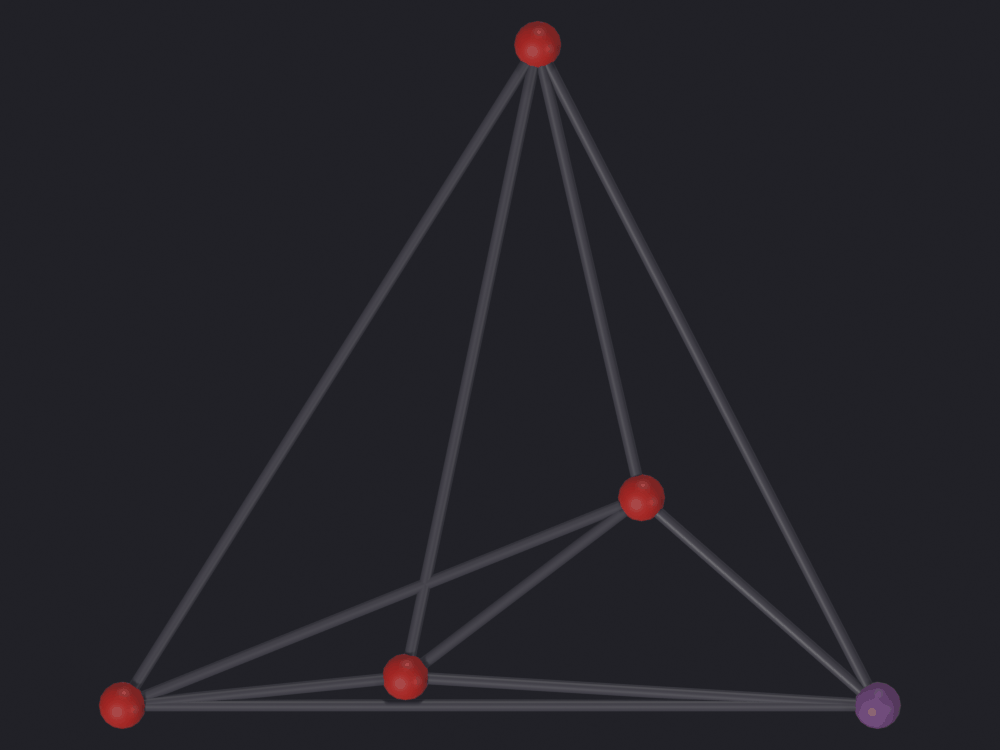

[PASS] 5_k5_best.png legible — 8.8% ink (healthy range 0.5–60%)


In [29]:
involved = set()
for first, second in topology.detect_edge_crossings_3d(
        [list(v.co) for v in best.data.vertices],
        [(e.vertices[0], e.vertices[1]) for e in best.data.edges],
        tolerance=0.01)["crossing_pairs"]:
    involved |= set(first) | set(second)
flags = [1 if i in involved else 0 for i in range(len(best.data.vertices))]
mesh = best.data
if "in_crossing" in mesh.attributes:
    mesh.attributes.remove(mesh.attributes["in_crossing"])
attr = mesh.attributes.new(name="in_crossing", type='INT', domain='POINT')
attr.data.foreach_set("value", flags)
print("vertices on a crossing edge:", sorted(involved), "of 5")
check("one vertex of the five is not involved", sum(flags) == 4)

nb.figure(best, "renders/17_topology/5_k5_best",
          look='ink', color_attribute="in_crossing",
          node_fraction=0.14, edge_color=LABEL_EDGE_COLOR)

Red: an endpoint of one of the two edges that cross. Purple: B,
the one vertex of the five that is not. The single crossing is the X just
above E, where the edge E-C leaves the face A B D through A-D. No drawing of
this graph has fewer.

> **Two properties of the detector.**
> `topology.detect_edge_crossings_3d` compares every pair of edges, O(E²),
> which is 1,128 pairs for this grid and would be 500,000 for a street network
> of a thousand edges. It works in **3D**, by closest approach between two
> segments with a distance tolerance the operator fixes at 0.01 Blender units
> (`topology_operators.py:185`). On a flat drawing that is a true crossing
> test, but two edges passing within 0.01 units of each other **without
> touching** are counted as a crossing, and 0.01 is not a fraction of the
> drawing: on a graph imported at `scale=0.001`, where a neighborhood spans
> one unit, it is 1 % of the whole scene. Two *collinear overlapping* segments
> are missed entirely, because the parallel case returns `False` at
> `topology.py:642` before any overlap test.

## 7 · The embedding surface

`visualize_surface`, labeled **Compute Embedding** in the UI, does two
things, and the second is not what the name suggests.

1. It recomputes the node positions with `nx.planar_layout`, the Chrobak-Payne
   straight-line drawing algorithm, and **rebuilds the mesh** from them. The
   result is guaranteed crossing-free.
2. It adds a child object: a single flat rectangle, sized to the bounding box
   of the new drawing plus a margin, one hundredth of a unit below it, with a
   semi-transparent blue material.

That rectangle is the "surface": a plane, not a torus and not a surface of
genus g, and nothing in it depends on anything section 4 computed. There is no
path in the add-on from a genus of 1 to a drawing on a torus.

It also requires `topo_is_planar` on the object already: run without a prior
`check_planarity` it returns "Run planarity check first" rather than running
one.

In [30]:
target = objects["Lattice"]
act(target)
before = [a.name for a in target.data.attributes]
print("attributes before:", before)

with nb.quiet():
    bpy.ops.scigraphs.visualize_surface()

surface = bpy.data.objects[target["topo_surface_child"]]
print("attributes after :", [a.name for a in target.data.attributes])
print(f"surface object   : {surface.name}, {len(surface.data.vertices)} verts, "
      f"{len(surface.data.polygons)} face, parent {surface.parent.name}")
print("layout recorded  :", target.get("topo_layout_type"))

act(target)
with nb.quiet():
    bpy.ops.scigraphs.validate_crossings()
print("crossings after the rebuild:", target.get("topo_num_crossings"))

check("the recomputed drawing is crossing-free",
      int(target["topo_num_crossings"]) == 0)
check("the surface is a single quad, not a surface of any genus",
      len(surface.data.polygons) == 1 and len(surface.data.vertices) == 4)
check("the mesh rebuild destroyed every attribute the analysis wrote",
      "face_id" in before and "face_id" not in
      [a.name for a in target.data.attributes])

attributes before: ['position', '.edge_verts', '.corner_vert', '.corner_edge', 'face_id']
Info: Planar embedding - edges DO NOT cross
attributes after : ['position', '.edge_verts', '.corner_vert', '.corner_edge', 'is_intersection']
surface object   : Lattice_Surface, 4 verts, 1 face, parent Lattice
layout recorded  : planar_crossing_free
Info: Embedding is crossing-free!
crossings after the rebuild: 0
[PASS] the recomputed drawing is crossing-free
[PASS] the surface is a single quad, not a surface of any genus
[PASS] the mesh rebuild destroyed every attribute the analysis wrote


True

> **Operator limitation.** `_rebuild_graph_mesh` replaces
> `obj.data` with a freshly built mesh
> (`SciGraphs/ui/operators/scigraphs/topology_operators.py:309`) and copies
> exactly one attribute onto it, `is_intersection`. Everything else goes:
> `face_id` from `compute_faces`, any centrality, any imported column, any
> color layer. It also sets `num_curve_verts = 0`, so a graph whose edges had
> a curved style comes back straight. Run it **before** the analysis, or
> accept that the analysis has to be re-run.

### The stale copy the operator leaves behind

A SciGraphs graph carries its node coordinates twice: in the mesh, and in the
`node_positions` custom property the native-graph contract defines.
`_rebuild_graph_mesh` updates `num_nodes`, `num_mesh_verts` and
`num_curve_verts` (`topology_operators.py:324`) and **does not update
`node_positions`**, so the property still describes the drawing the embedding
replaced.

In [31]:
stored = np.asarray(list(target["node_positions"]), dtype=float).reshape(-1, 3)
actual = np.array([list(v.co) for v in target.data.vertices])
spacing_stored = float(np.median(
                       [np.sort(np.linalg.norm(stored - p, axis=1))[1] for p in stored]))
spacing_actual = float(np.median(
                       [np.sort(np.linalg.norm(actual - p, axis=1))[1] for p in actual]))
cloud, source = sg.render.node_cloud(target)
print(f"largest disagreement between property and mesh: "
      f"{np.abs(stored - actual).max():.2f} Blender units")
print(f"median node spacing   property {spacing_stored:.3f}   mesh {spacing_actual:.3f}")
print(f"sg.render.node_cloud reads {source!r}")

check("node_positions still describes the drawing that was replaced",
      not np.allclose(stored, actual))
check("so every radius derived from node spacing comes out far too big",
      spacing_stored / spacing_actual > 5,
      f"{spacing_stored / spacing_actual:.1f}x")

largest disagreement between property and mesh: 8.93 Blender units
median node spacing   property 2.000   mesh 0.227
sg.render.node_cloud reads 'node_positions'
[PASS] node_positions still describes the drawing that was replaced
[PASS] so every radius derived from node spacing comes out far too big — 8.8x


True

Everything that sizes a glyph from node spacing reads that
property first (`sg.render.node_cloud` does, and so does the add-on's own
preview autoscale), so the node radius comes out 8.8 times too large and the
figure below would be a row of merged beads. The notebook writes the property
back in line with the mesh before rendering.

`geometry.update_node_positions_from_property()` copies the property onto the
mesh, and **every layout operator** calls it
(`SciGraphs/ui/operators/scigraphs/data_operators.py:40`), so a layout run
after `visualize_surface` writes the old coordinates back over the
crossing-free embedding without a word. Demonstrated below on a copy, because
it is destructive.

In [32]:
victim = target.copy()
victim.data = target.data.copy()
use_collection().objects.link(victim)
victim.name = "Lattice_Reverted"
geometry.update_node_positions_from_property(victim)
reverted = np.array([list(v.co) for v in victim.data.vertices])
print("after update_node_positions_from_property, the mesh is the old drawing:",
      bool(np.allclose(reverted, stored)))
check("a layout would silently undo the planar embedding",
      np.allclose(reverted, stored))
bpy.data.objects.remove(victim, do_unlink=True)

# So the figure below is sized from the drawing it actually shows.
target["node_positions"] = actual.flatten().tolist()
print("node_positions rewritten from the mesh; median spacing now",
      f"{spacing_actual:.3f}")

after update_node_positions_from_property, the mesh is the old drawing: True
[PASS] a layout would silently undo the planar embedding
node_positions rewritten from the mesh; median spacing now 0.227


### The figure

`isolate=False` so the plate is in the frame with the graph, the only way to
see what the operator added. The ceiling of the legibility check is lifted for
the reason notebook 13 gives: the plate reaches the corners of the frame, so
`ink()` measures where the plate stops rather than whether the graph reads.
The floor still bites.

`isolate=False` means *every* mesh in the scene, and by this point the scene
holds thirteen graphs on top of one another. Everything but this graph and its
plate is handed to `hide=`, which keeps the framing on the lattice. Without it
the frame comes back as all thirteen drawings superimposed, a quiet failure
that looks like a render bug rather than a scene-management one.

The color is `node_degree`, computed here because the rebuild took everything
else. On the triangular lattice it runs from 2 at the corners to 6 in the
interior, so it says where the boundary is, and the boundary is what a planar
embedding rearranges most.

The figure is easy to read as a failure and is not one. Chrobak-Payne
guarantees a **crossing-free** straight-line drawing on an integer grid and
nothing about how it looks. Every node lands on a lattice of pitch 0.227 units
and the whole graph collapses into a wide, shallow wedge, with long chords
running almost horizontally underneath it. Compare figure 1, the same kind of
object drawn by hand.

degree range: 2 - 6
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_degree  ·  node_degree -> turbo [log]  [2 … 6] on Point


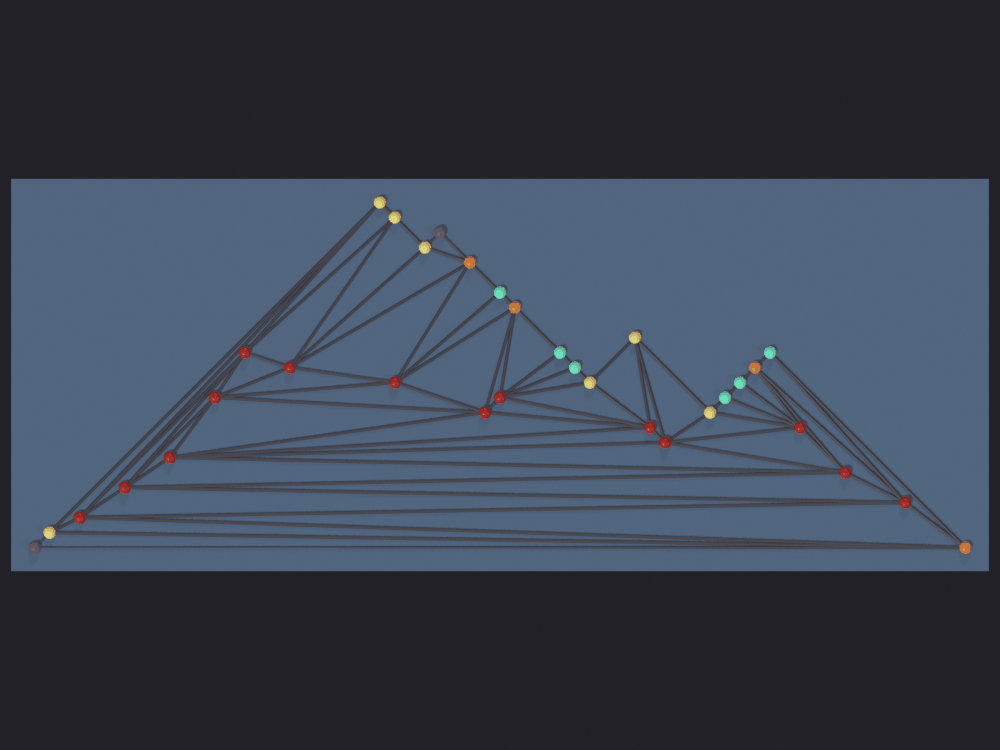

[PASS] 6_surface.png legible — 51.4% ink (healthy range 0.5–100%)


True

In [33]:
degrees = [d for _, d in sorted(lattice.degree())]
mesh = target.data
if "node_degree" in mesh.attributes:
    mesh.attributes.remove(mesh.attributes["node_degree"])
attr = mesh.attributes.new(name="node_degree", type='INT', domain='POINT')
attr.data.foreach_set("value", degrees[:len(mesh.vertices)])
print("degree range:", min(degrees), "-", max(degrees))

crowd = [o for o in bpy.data.objects
         if o.type == 'MESH' and o not in (target, surface)]
path = nb.render(target, "renders/17_topology/6_surface",
                 isolate=False, hide=crowd, look='ink',
                 color_attribute="node_degree",
                 node_fraction=0.30,
                 edge_color=LABEL_EDGE_COLOR, verbose=False)
nb.show(path)
nb.check_render(path, maximum=1.0)

### `toggle_topo_surface` and `remove_topo_surface`

The same pair as for the dual, reading `topo_surface_child` off the active
object. `remove` is the one that matters under a live kernel: the plate is a
real object in the scene and every later `isolate=False` render composes
against it.

In [34]:
act(target)
with nb.quiet():
    bpy.ops.scigraphs.toggle_topo_surface()
print("surface hidden:", surface.hide_viewport)
with nb.quiet():
    bpy.ops.scigraphs.toggle_topo_surface()
check("toggling the surface twice is the identity", not surface.hide_viewport)

Info: Surface hidden
surface hidden: True
Info: Surface visible
[PASS] toggling the surface twice is the identity


True

## 8 · Cleaning up after the operators

`create_dual_graph` and `visualize_surface` leave objects behind, and under
the single shared kernel these notebooks run in, that state is still there
when the next notebook starts. Both have a `remove_*` operator; the plain
graphs are ours to clear.

In [35]:
for name, obj in list(objects.items()):
    if obj.get("topo_dual_child"):
        act(obj)
        with nb.quiet():
            bpy.ops.scigraphs.remove_dual_graph()
    if obj.get("topo_surface_child"):
        act(obj)
        with nb.quiet():
            bpy.ops.scigraphs.remove_topo_surface()

leftover = [o.name for o in bpy.data.objects
            if o.name.endswith("_Dual") or o.name.endswith("_Surface")]
print("dual / surface objects left in the scene:", leftover or "none")
check("the operators' side objects are gone", not leftover)
check("the keys that pointed at them are gone",
      not any(o.get("topo_dual_child") or o.get("topo_surface_child")
      for o in bpy.data.objects))

Info: Dual graph removed
Info: Surface removed
dual / surface objects left in the scene: none
[PASS] the operators' side objects are gone
[PASS] the keys that pointed at them are gone


True

## 9 · Save

Every graph, what the operators said, and what the answer is.

In [36]:
output_dir = nb.out("05_topology")
output_dir.mkdir(parents=True, exist_ok=True)

rows = ["graph,V,E,known_planar,operator_planar,F,chi,genus_bound,known_genus"]
for name, graph, _positions, planar in CAST:
    obj = objects[name]
    rows.append(",".join(str(x) for x in (
                name, graph.number_of_nodes(), graph.number_of_edges(),
                planar, verdicts[name],
                obj.get("topo_num_faces", ""), obj.get("topo_euler_chi", ""),
                obj.get("topo_genus_lower_bound", ""),
                GENUS_KNOWN.get(name, ""))))
(output_dir / "topology_cases.csv").write_text("\n".join(rows) + "\n",
                                               encoding="utf-8")

faces_rows = ["face_id,degree,nodes"]
for index, face in enumerate(faces):
    faces_rows.append(f"{index},{len(face)},\"{' '.join(str(v) for v in face)}\"")
(output_dir / "grid_faces.csv").write_text("\n".join(faces_rows) + "\n",
                                           encoding="utf-8")

print("written to", nb.rel(output_dir))
for entry in sorted(output_dir.iterdir()):
    print("  ", entry.name, f"{entry.stat().st_size / 1e3:.1f} kB")

written to notebooks/out/05_topology
   grid_faces.csv 0.4 kB
   topology_cases.csv 0.5 kB


## Rendering

Six figures, all EEVEE through `nb.figure()` / `render_eevee()`,
all `look='ink'` on turbo, all straight down through an orthographic camera:
the suite's style since notebook 13, so these plane graphs read the same way
as the street networks in 01 and 05.

What this notebook had to solve that the others did not: **its attributes are
categorical or binary, and turbo is neither.** Hence the measured ramp
separations, the clipping, the neutral at `(0.060, 0.056, 0.071)`, and node
sizes derived from each drawing rather than left at the 0.35 default.

**Two figures were made and thrown away**: convex K₅ and convex K₃,₃ colored
by `edge_crossings` both render as one flat color. The weakest figure that
survived is **figure 2**, the dual, where the outer face's vertex is placed
15 % of the median spacing from its nearest neighbor and half disappears
behind it. No render setting fixes that; the operator put it there.

> The **Vulkan** warning that applies to the SciGraphs GPU engine applies
> here too if you switch to it: `gpu.state.point_size_set` is a no-op for the
> add-on's shaders on Vulkan, the Linux default, so `POINT` and `DISK` nodes
> rasterize one pixel wide. Start Blender with `--gpu-backend opengl`.

## Summary

| Operator | Verified against |
|---|---|
| `check_planarity` | the literature, 13/13 correct |
| `compute_faces` | V − E + F = 2 on five connected planar graphs; Σ deg(f) = 2E; F = 1 for a tree |
| `calculate_genus` | exact 0 when planar; a lower bound otherwise, tight on K₅, K₇, K₈ |
| `create_dual_graph` | V\* = F ✓; E\* < E ✗ |
| `validate_crossings` | an interleaving oracle, which gives C(n,4) on convex K₄, K₅, K₆ |
| `visualize_surface` | 0 crossings after the rebuild |

Six things measured here that are not written down anywhere else.

1. `calculate_genus` reports `Genus >= 0` for two graphs it has just declared
   non-planar (§4, `topology.py:307`).
2. The Kuratowski classifier is dead code (§2, `topology.py:356`).
3. The geometric dual is the *simple* dual: a 48-edge grid yields a 29-edge
   dual of which 28 reach the mesh, with the outer face's vertex at the mean
   of the perimeter (§5, `topology.py:246`, `topology_operators.py:468`).
4. Euler's identity holds in the form χ = 2C, and an edgeless component
   contributes no face at all (§3, `topology.py:62`).
5. `visualize_surface` leaves `node_positions` describing the drawing it just
   replaced: the two copies disagree by up to 8.9 Blender units, 2.000 median
   spacing against the mesh's 0.227, so every radius derived from spacing
   comes out 8.8x too large, and a later layout copies the stale property back
   over the embedding (§7, `topology_operators.py:324`,
   `data_operators.py:40`).
6. A crossing count does not survive a layout: `rebuild_edges` zeroes every
   EDGE-domain attribute (§6, `geometry.py:1226`).

`validate_crossings` is not on that list: C(n,4) for convex K₄, K₅ and K₆, the
same answer as an independent interleaving count on convex K₃,₃, 78 for the
grid drawn on a circle and 0 for the same graph drawn as a lattice. That
number is about the drawing, and moving it is **16 · Layouts**' job.